# H&M Fashion Recommendation – EDA

Dataset bao gồm 3 bảng:
- **articles**: 105 542 sản phẩm thời trang
- **customers**: 1 371 980 khách hàng
- **transactions**: 31 788 324 giao dịch (09/2018 – 09/2020)

> **Task**: Dự đoán 12 sản phẩm mỗi khách hàng sẽ mua trong tuần cuối cùng.
> **Metric**: MAP@12 


In [1]:
import warnings
warnings.filterwarnings("ignore")
                                  
import asyncio
asyncio.set_event_loop_policy(asyncio.WindowsSelectorEventLoopPolicy())                                  

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates                                  
import seaborn as sns
import textwrap
from pathlib import Path

ROOT = Path.cwd().resolve().parent
FIG_DIR = ROOT / "figures"
FIG_DIR.mkdir(exist_ok=True)                                                                    

sns.set_theme(style="white", palette="muted", font_scale=1.1)

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.grid": False,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
                                  
plt.rcParams["figure.dpi"] = 110

DATA = Path("../data")


In [2]:
articles     = pd.read_parquet(DATA / "articles.parquet")
customers    = pd.read_parquet(DATA / "customers.parquet")
transactions = pd.read_parquet(DATA / "transactions.parquet")

print(f"articles     : {articles.shape}")
print(f"customers    : {customers.shape}")
print(f"transactions : {transactions.shape}")


articles     : (105542, 25)
customers    : (1371980, 7)
transactions : (31788324, 5)


## 1. Tổng quan Schema

In [3]:
def df_summary(df: pd.DataFrame, name: str) -> pd.DataFrame:
    summary = pd.DataFrame({
        "dtype"  : df.dtypes,
        "non_null": df.notnull().sum(),
        "null_pct": (df.isnull().mean() * 100).round(2),
        "nunique": df.nunique(),
    })
    print(f"\n{'='*55}\n  {name}\n{'='*55}")
    print(summary.to_string())
    return summary

_ = df_summary(articles,     "ARTICLES")
_ = df_summary(customers,    "CUSTOMERS")
_ = df_summary(transactions, "TRANSACTIONS")



  ARTICLES
                               dtype  non_null  null_pct  nunique
article_id                    string    105542      0.00   105542
product_code                  string    105542      0.00    47224
prod_name                        str    105542      0.00    45875
product_type_no                int64    105542      0.00      132
product_type_name                str    105542      0.00      131
product_group_name               str    105542      0.00       19
graphical_appearance_no        int64    105542      0.00       30
graphical_appearance_name        str    105542      0.00       30
colour_group_code              int64    105542      0.00       50
colour_group_name                str    105542      0.00       50
perceived_colour_value_id      int64    105542      0.00        8
perceived_colour_value_name      str    105542      0.00        8
perceived_colour_master_id     int64    105542      0.00       20
perceived_colour_master_name     str    105542      0.00       2

## 2. Missing Values

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (df, title) in zip(axes, [
    (articles,  "Articles"),
    (customers, "Customers"),
    (transactions, "Transactions"),
]):
    null_pct = df.isnull().mean() * 100
    null_pct = null_pct[null_pct > 0]
    if null_pct.empty:
        ax.text(0.5, 0.5, "No missing values", ha="center", va="center",
                transform=ax.transAxes, fontsize=13)
        ax.set_title(title)
    else:
        null_pct.sort_values().plot(kind="barh", ax=ax, color="salmon")
        ax.set_xlabel("Missing %")
        ax.set_title(title)
        for bar in ax.patches:
            ax.text(bar.get_width() +0.03 , bar.get_y() + bar.get_height() / 2,
                    f"{bar.get_width():.1f}%", va="center", fontsize=9)
plt.tight_layout()
plt.subplots_adjust(wspace=1)
fig.suptitle("Missing Values Overview", fontsize=18, y=1.05)
plt.savefig(FIG_DIR / "missing_values.png", bbox_inches="tight")
plt.show()


## 3. Transactions – Phân tích theo thời gian

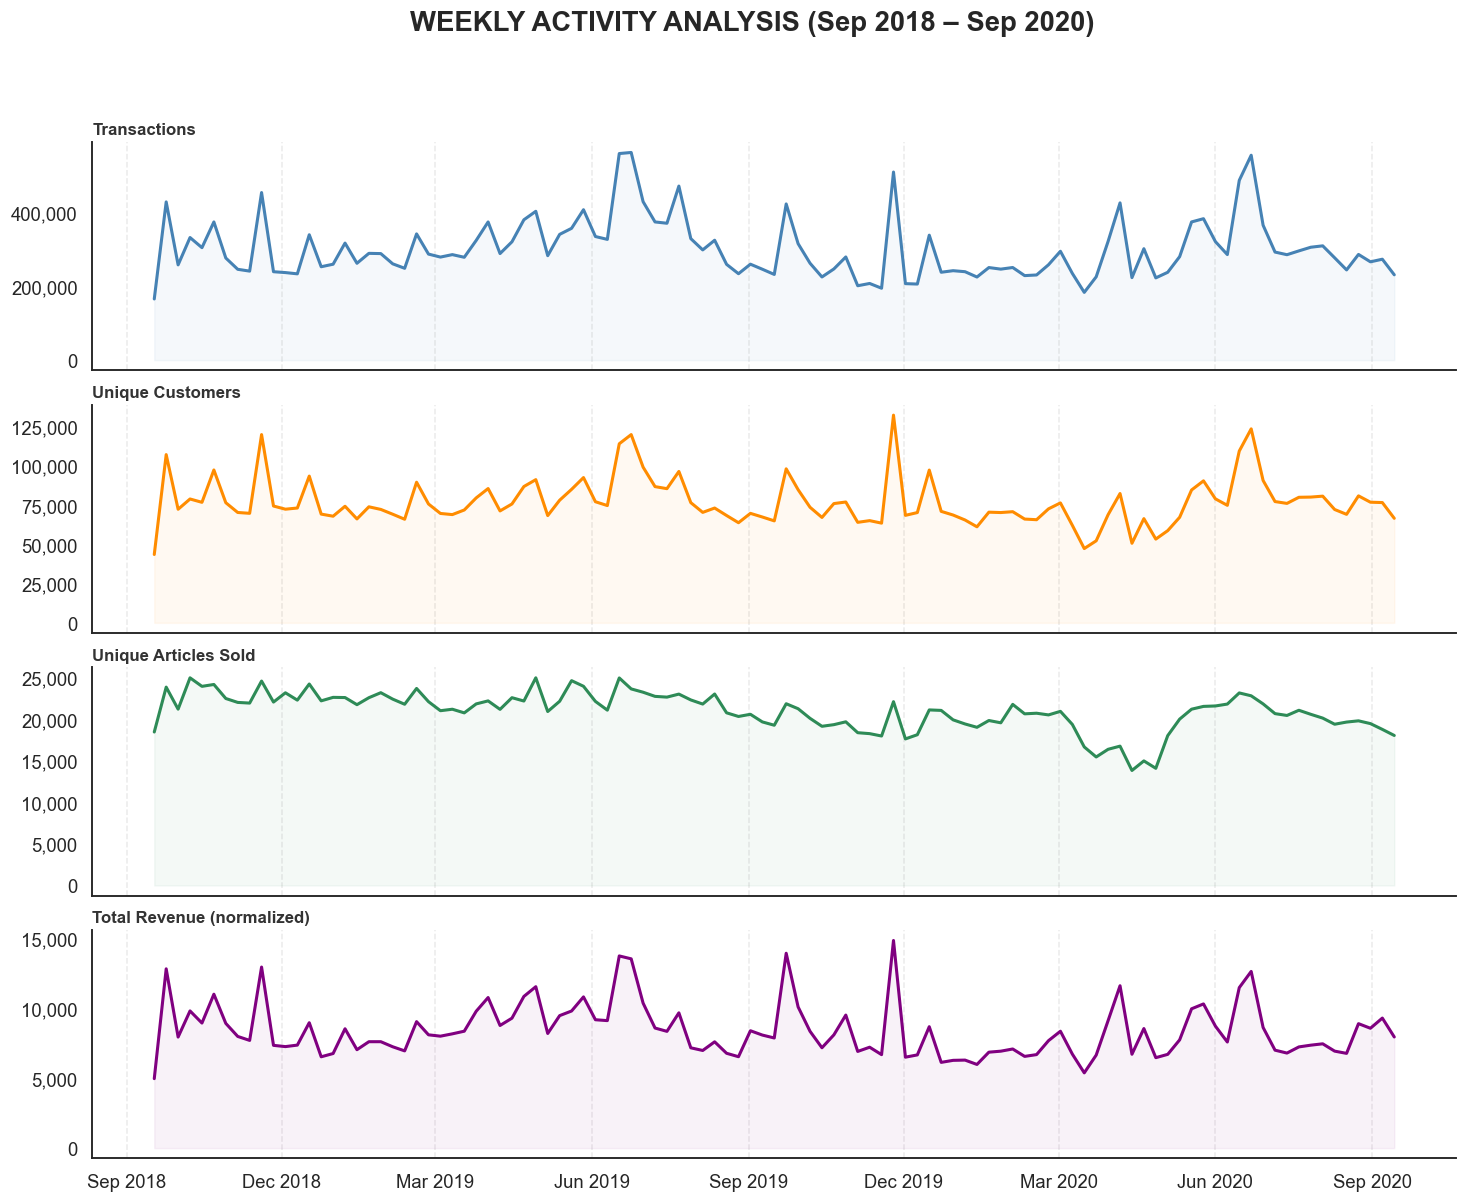

In [5]:
# 1. Tiền xử lý dữ liệu
tx = transactions.copy()
tx["year_week"] = tx["t_dat"].dt.to_period("W")

weekly = tx.groupby("year_week").agg(
    n_transactions=("article_id", "count"),
    n_customers=("customer_id", "nunique"),
    n_articles=("article_id", "nunique"),
    revenue=("price", "sum"),
).reset_index()

# Loại bỏ tuần cuối cùng nếu dữ liệu bị thiếu/sụt giảm bất thường
weekly = weekly.iloc[:-1] 

# Chuyển Period sang Datetime để Matplotlib xử lý trục thời gian tốt hơn
weekly["week_start"] = weekly["year_week"].dt.to_timestamp()

# 2. Plotting
fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True, gridspec_kw={'hspace': 0.15})

metrics = [
    ("n_transactions", "Transactions", "steelblue"),
    ("n_customers",    "Unique Customers", "darkorange"),
    ("n_articles",     "Unique Articles Sold", "seagreen"),
    ("revenue",        "Total Revenue (normalized)", "purple"),
]

for i, (ax, (col, label, color)) in enumerate(zip(axes, metrics)):
    # Dùng Line chart thuần túy, giảm độ đậm của fill_between
    ax.plot(weekly["week_start"], weekly[col], color=color, linewidth=2)
    ax.fill_between(weekly["week_start"], weekly[col], alpha=0.05, color=color)
    
    # Tối ưu Trục Y: Để tên trục nằm ngang phía trên biểu đồ cho thoáng
    ax.set_title(label, loc='left', fontsize=11, fontweight='bold', color='#333333', pad=5)
    
    # Thêm gridline dọc mờ
    ax.grid(axis='x', linestyle='--', alpha=0.4)
    
    # Bỏ khung viền trên và phải cho hiện đại
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Định dạng số trục Y (thêm dấu phẩy ngăn cách hàng nghìn)
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

# 3. Tối ưu Trục X (Ngày tháng)
# Định dạng: Hiển thị Tháng - Năm (Ví dụ: Jan 2019)
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
# Cách 3 tháng hiển thị 1 nhãn để tránh dày đặc
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))

plt.xticks(rotation=0, ha='center') # Để nằm ngang cho dễ đọc
axes[-1].set_xlabel("", fontsize=12, labelpad=10)

plt.suptitle("WEEKLY ACTIVITY ANALYSIS (Sep 2018 – Sep 2020)", 
             fontsize=18, fontweight='bold', y=0.98)

#plt.tight_layout() # Đã dùng hspace trong gridspec_kw nên có thể cân nhắc bỏ tight_layout
plt.savefig(FIG_DIR / "weekly_activity.png", bbox_inches="tight")
plt.show()


Text(0.5, 1.0, 'Days since last purchase distribution')

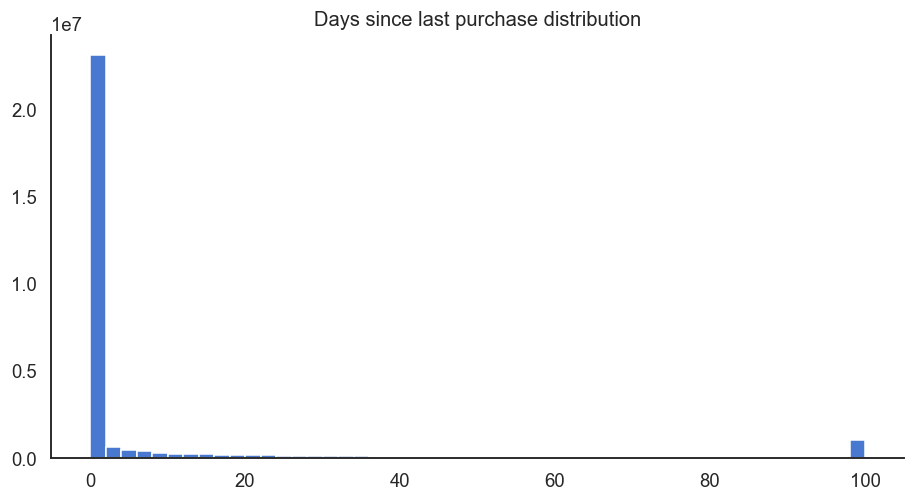

In [6]:
tx_sorted = tx.sort_values(["customer_id", "t_dat"])
tx_sorted["prev_date"] = tx_sorted.groupby("customer_id")["t_dat"].shift(1)
tx_sorted["days_since_last"] = (tx_sorted["t_dat"] - tx_sorted["prev_date"]).dt.days

fig, ax = plt.subplots(figsize=(10,5))
ax.hist(tx_sorted["days_since_last"].dropna().clip(0, 100), bins=50)
ax.set_title("Days since last purchase distribution")

Text(0.5, 1.0, 'Customer lifetime (days)')

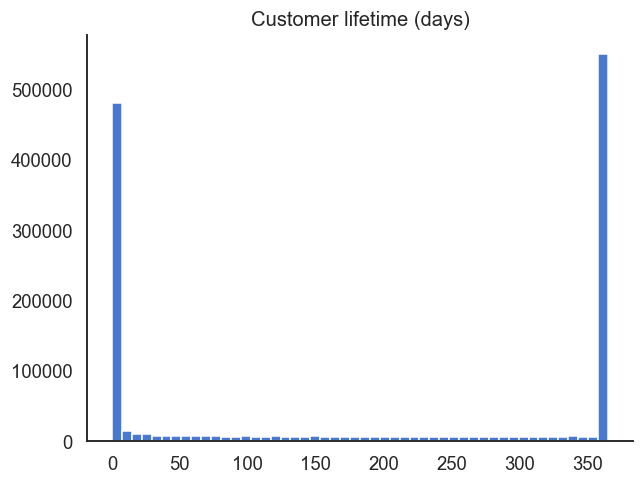

In [7]:
cust_life = tx.groupby("customer_id")["t_dat"].agg(["min", "max"])
cust_life["lifetime_days"] = (cust_life["max"] - cust_life["min"]).dt.days

plt.hist(cust_life["lifetime_days"].clip(0, 365), bins=50)
plt.title("Customer lifetime (days)")

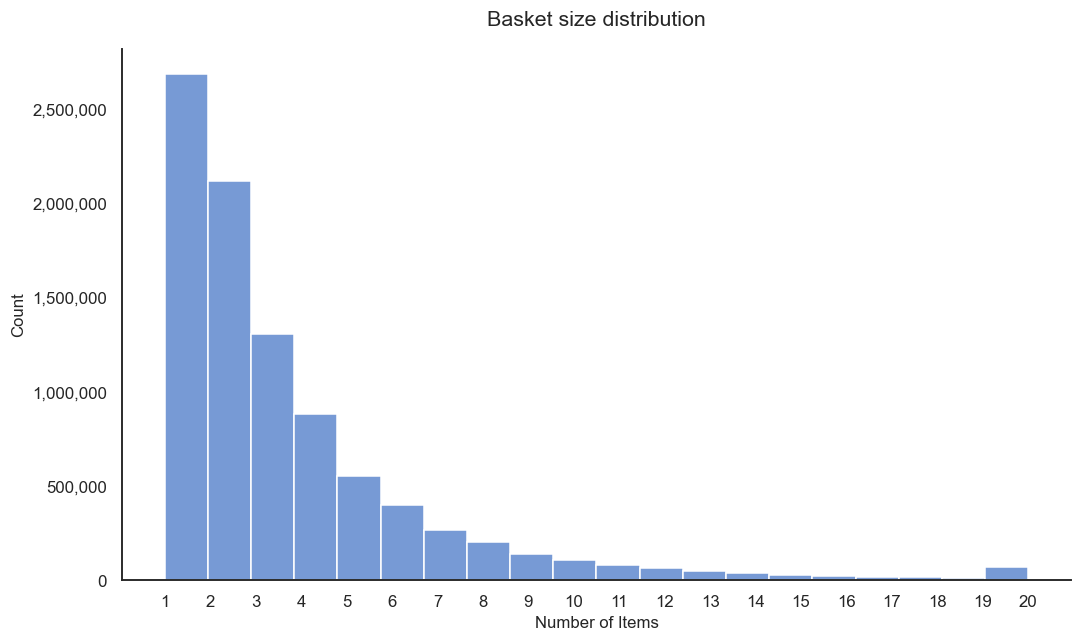

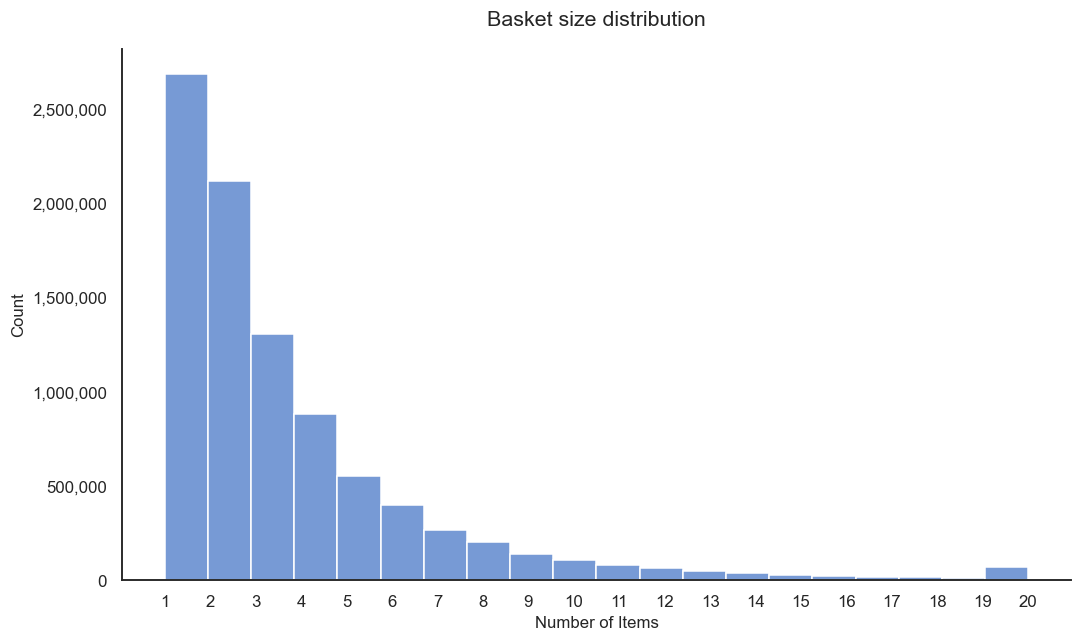

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker ##

# 1. Tính toán dữ liệu
basket_size = tx.groupby(["customer_id", "t_dat"]).size()

# 2. Cấu hình phong cách biểu đồ
sns.set_theme(style="white") # Giữ style trắng tối giản giống image_5e6730.png
plt.figure(figsize=(10, 6))

# 3. Vẽ histogram
# Sử dụng bins=20 để mỗi cột khớp với một đơn vị (từ 1 đến 20)
ax = sns.histplot(basket_size.clip(0, 20), 
                  bins=20, 
                  color="#4A79C7", 
                  edgecolor="white")

# 4. Định dạng dấu phẩy cho trục Y
# 'funcformatter' với f-string '{x:,.0f}' sẽ thêm dấu phẩy tự động
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

# 5. Tinh chỉnh tiêu đề và nhãn
plt.title("Basket size distribution", fontsize=14, pad=15)
plt.xlabel("Number of Items", fontsize=11)
plt.ylabel("Count", fontsize=11)

# 6. Điều chỉnh trục X để hiển thị các số nguyên từ 1-20
plt.xticks(range(1, 21))

# 7. Loại bỏ khung viền thừa (Top và Right)
sns.despine()

plt.tight_layout()
plt.show()
# 1. Tính toán dữ liệu
basket_size = tx.groupby(["customer_id", "t_dat"]).size()

# 2. Cấu hình phong cách biểu đồ
sns.set_theme(style="white") # Giữ style trắng tối giản giống image_5e6730.png
plt.figure(figsize=(10, 6))

# 3. Vẽ histogram
# Sử dụng bins=20 để mỗi cột khớp với một đơn vị (từ 1 đến 20)
ax = sns.histplot(basket_size.clip(0, 20), 
                  bins=20, 
                  color="#4A79C7", 
                  edgecolor="white")

# 4. Định dạng dấu phẩy cho trục Y
# 'funcformatter' với f-string '{x:,.0f}' sẽ thêm dấu phẩy tự động
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

# 5. Tinh chỉnh tiêu đề và nhãn
plt.title("Basket size distribution", fontsize=14, pad=15)
plt.xlabel("Number of Items", fontsize=11)
plt.ylabel("Count", fontsize=11)

# 6. Điều chỉnh trục X để hiển thị các số nguyên từ 1-20
plt.xticks(range(1, 21))

# 7. Loại bỏ khung viền thừa (Top và Right)
sns.despine()

plt.tight_layout()
plt.show()

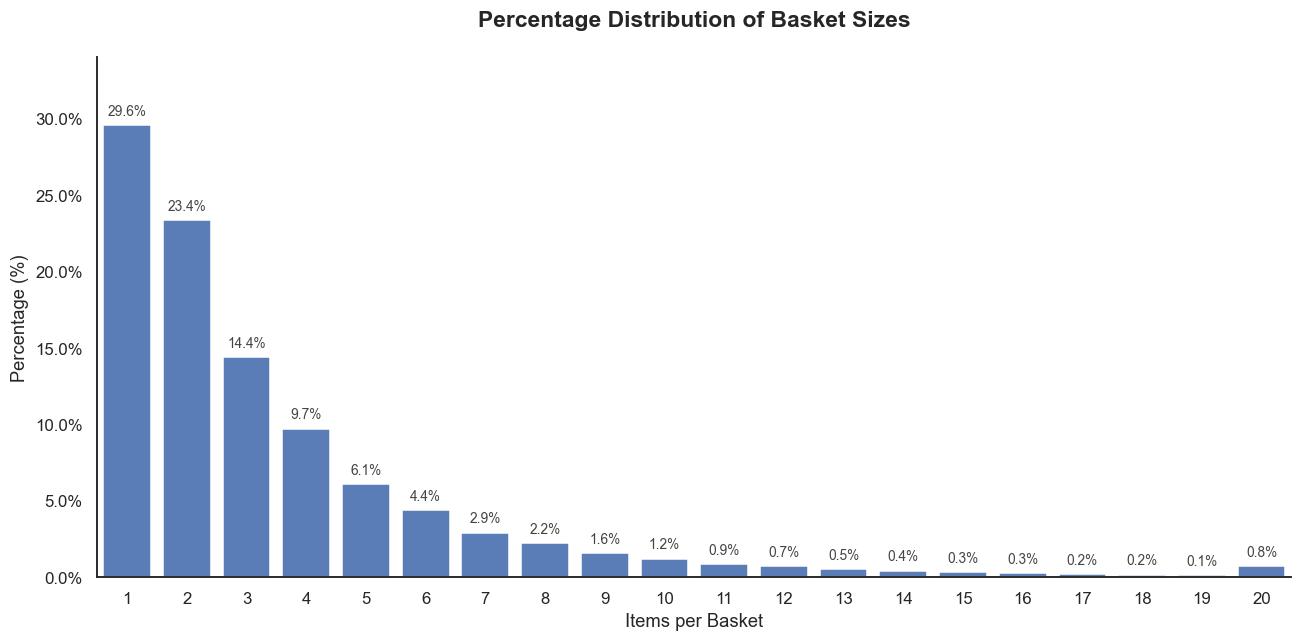

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

# 1. Tính toán basket size
basket_size = tx.groupby(["customer_id", "t_dat"]).size().clip(0, 20)

# 2. Tính toán tỉ lệ phần trăm
# counts sẽ chứa số lượng lần xuất hiện của mỗi size (1, 2, 3...)
counts = basket_size.value_counts(normalize=True).sort_index() * 100

# 3. Cấu hình giao diện
sns.set_theme(style="white")
plt.figure(figsize=(12, 6))

# 4. Vẽ biểu đồ cột
ax = sns.barplot(x=counts.index, y=counts.values, color="#4A79C7")

# 5. Thêm nhãn phần trăm trên đầu mỗi cột
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=9,
                color='#444444')

# 6. Định dạng các trục
plt.title("Percentage Distribution of Basket Sizes", fontsize=15, pad=20, fontweight='bold')
plt.xlabel("Items per Basket", fontsize=12)
plt.ylabel("Percentage (%)", fontsize=12)

# Thêm ký hiệu % vào trục Y
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

# Giới hạn trục Y cao hơn một chút để không bị đè nhãn số
plt.ylim(0, counts.max() * 1.15)

# Tối giản khung hình
sns.despine()

plt.tight_layout()
plt.show()

In [13]:
from itertools import combinations
from collections import Counter

sample_tx = tx.sample(500_000, random_state=42)

pairs = Counter()
for _, group in sample_tx.groupby(["customer_id", "t_dat"]):
    items = group["article_id"].unique()
    pairs.update(combinations(items, 2))

top_pairs = pairs.most_common(20)

In [ ]:
# map article_id → product name
id2name = articles.set_index("article_id")["prod_name"].to_dict()

pairs_df["pair_name"] = pairs_df["pair"].apply(
    lambda x: f"{id2name.get(x[0], 'NA')} | {id2name.get(x[1], 'NA')}"
)

plt.figure(figsize=(12, 8))
plt.barh(pairs_df["pair_name"][::-1], pairs_df["count"][::-1])

plt.xlabel("Co-occurrence Count")
plt.title("Top 20 Co-purchased Product Pairs")

plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

channel_counts = tx["sales_channel_id"].value_counts()
channel_labels = channel_counts.index.map({1: "Store (1)", 2: "Online (2)"})
axes[0].pie(channel_counts, labels=channel_labels, autopct="%1.1f%%",
            colors=["#4C72B0", "#DD8452"], startangle=90)
axes[0].set_title("Sales Channel Distribution")

channel_price = tx.groupby("sales_channel_id")["price"].mean()
axes[1].bar(["Store (1)", "Online (2)"], channel_price.values,
            color=["#4C72B0", "#DD8452"])
axes[1].set_ylabel("Mean Price")
axes[1].set_title("Average Price by Channel")

plt.tight_layout()
plt.savefig(FIG_DIR / "sales_channel.png", bbox_inches="tight")
plt.show()
print(channel_counts.rename(index={1: "Store", 2: "Online"}))


## 4. Phân phối Giá

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Subplot 0: Histogram
sample_price = tx["price"].sample(200_000, random_state=42)
axes[0].hist(sample_price, bins=80, color="steelblue", edgecolor="white", linewidth=0.3)
axes[0].set_xlabel("Price")
axes[0].set_ylabel("Count")
axes[0].set_title("Price Distribution (sample 200k)")
axes[0].yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

# Subplot 1: Boxplot
axes[1].boxplot(
    [tx[tx["sales_channel_id"] == c]["price"].sample(50_000, random_state=42)
     for c in [1, 2]],
    labels=["Store (1)", "Online (2)"],
    patch_artist=True,
    boxprops=dict(facecolor="#4C72B0", color="navy"),
)
axes[1].set_ylabel("Price")
axes[1].set_title("Price by Sales Channel")

plt.tight_layout()
plt.savefig(FIG_DIR / "price_dist.png", bbox_inches="tight")
plt.show()

print("Price quantiles:")
print(tx["price"].quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).round(4))


## 5. Phân tích Khách hàng

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6)) 

# 1. Age distribution
age_valid = customers["age"].dropna()
axes[0].hist(age_valid, bins=50, color="darkorange", edgecolor="white", linewidth=0.3)
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Count")
axes[0].set_title(f"Age Distribution (n={len(age_valid):,})")
axes[0].axvline(age_valid.mean(), color="red", linestyle="--", label=f"Mean={age_valid.mean():.1f}")
axes[0].axvline(age_valid.median(), color="green", linestyle="--", label=f"Median={age_valid.median():.1f}")
axes[0].legend()
axes[0].yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

# 2. Club membership
club = customers["club_member_status"].value_counts()
axes[1].bar(club.index, club.values, color=["#4C72B0", "#DD8452", "#55A868"])
axes[1].set_title("Club Member Status")
axes[1].set_ylabel("Count")
axes[1].yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                 f"{bar.get_height()/1e6:.2f}M", ha="center", fontsize=10, fontweight='bold')

# 3. Fashion news frequency
fn = customers["fashion_news_frequency"].value_counts()
axes[2].bar(fn.index, fn.values, color=["#4C72B0", "#DD8452", "#55A868"])
axes[2].set_title("Fashion News Frequency")
axes[2].set_ylabel("Count")
axes[2].yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

for bar in axes[2].patches:
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                 f"{bar.get_height()/1e6:.2f}M", ha="center", fontsize=10, fontweight='bold')

plt.suptitle("CUSTOMER PROFILE ANALYSIS", fontsize=20, fontweight='bold', y=1.05)

plt.tight_layout()
plt.savefig(FIG_DIR / "customer_profile.png", bbox_inches="tight")
plt.show()


In [ ]:
cust_purchase_count = tx.groupby("customer_id").size()

fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 

# 1. Histogram 
axes[0].hist(cust_purchase_count.clip(upper=100), bins=60,
             color="steelblue", edgecolor="white", linewidth=0.3)
axes[0].set_xlabel("Purchases per Customer (clipped at 100)")
axes[0].set_ylabel("Count")
axes[0].set_title("Customer Purchase Frequency")

axes[0].yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

# 2. CDF 
cdf = cust_purchase_count.value_counts().sort_index().cumsum() / len(cust_purchase_count)
axes[1].plot(cdf.index[:200], cdf.values[:200], color="steelblue", linewidth=2)
axes[1].set_xlabel("Purchases per Customer")
axes[1].set_ylabel("Cumulative Fraction of Customers")
axes[1].set_title("CDF – Purchase Count")

for p in [0.5, 0.8, 0.95]:
    val = (cdf >= p).idxmax()
    axes[1].axhline(p, linestyle="--", linewidth=0.8, color="gray")
    axes[1].axvline(val, linestyle="--", linewidth=0.8, color="gray")
    axes[1].text(val + 1, p - 0.02, f"{val} purchases = {p*100:.0f}%", fontsize=9, fontweight='bold')

plt.suptitle("CUSTOMER PURCHASE BEHAVIOR", fontsize=18, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig(FIG_DIR / "customer_purchase_freq.png", bbox_inches="tight")
plt.show()

print("Purchase count stats per customer:")
print(cust_purchase_count.describe().round(1))


## 6. Phân tích Sản phẩm

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Product group (Top 12)
pg = articles["product_group_name"].value_counts().head(12)
axes[0, 0].barh(pg.index[::-1], pg.values[::-1], color="steelblue")
axes[0, 0].set_xlabel("Count")
axes[0, 0].set_title("Product Groups (Top 12)", fontweight='bold')
axes[0, 0].xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

# 2. Index group (department) - Pie Chart
ig = articles["index_group_name"].value_counts()
axes[0, 1].pie(ig, labels=ig.index, autopct="%1.1f%%", startangle=90,
               colors=sns.color_palette("muted", len(ig)),
               wedgeprops={'edgecolor': 'white', 'linewidth': 1})
axes[0, 1].set_title("Index Group Distribution", fontweight='bold')

# 3. Colour groups (Top 15)
cg = articles["colour_group_name"].value_counts().head(15)
axes[1, 0].barh(cg.index[::-1], cg.values[::-1], color="coral")
axes[1, 0].set_xlabel("Count")
axes[1, 0].set_title("Top 15 Colour Groups", fontweight='bold')
axes[1, 0].xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

# 4. Garment groups (Top 12)
gg = articles["garment_group_name"].value_counts().head(12)
axes[1, 1].barh(gg.index[::-1], gg.values[::-1], color="seagreen")
axes[1, 1].set_xlabel("Count")
axes[1, 1].set_title("Top 12 Garment Groups", fontweight='bold')
axes[1, 1].xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

for i, j in [(0,0), (1,0), (1,1)]:
    axes[i, j].grid(axis='x', linestyle='--', alpha=0.6)

plt.suptitle("ARTICLE & PRODUCT PROFILE ANALYSIS", fontsize=22, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig(FIG_DIR / "article_profile.png", bbox_inches="tight")
plt.show()


In [ ]:
article_counts = tx.groupby("article_id").size().sort_values(ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Article Popularity Distribution
axes[0].hist(article_counts.clip(upper=3000), bins=60,
             color="purple", edgecolor="white", linewidth=0.3)
axes[0].set_xlabel("Times Purchased (clipped at 3000)")
axes[0].set_ylabel("Count")
axes[0].set_title("Article Popularity Distribution", fontweight='bold')
axes[0].yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

# 2. Top 20 Most Purchased Articles
top20 = article_counts.head(20).reset_index()
top20.columns = ["article_id", "count"]
top20 = top20.merge(articles[["article_id", "prod_name"]], on="article_id", how="left")
top20["label"] = top20["prod_name"]

axes[1].barh(top20["label"][::-1], top20["count"][::-1], color="purple")
axes[1].set_xlabel("Transactions")
axes[1].set_title("Top 20 Most Purchased Articles", fontweight='bold')
axes[1].xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
axes[1].grid(axis='x', linestyle='--', alpha=0.5)

plt.suptitle("ARTICLE POPULARITY & SALES ANALYSIS", fontsize=18, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig(FIG_DIR / "article_popularity.png", bbox_inches="tight")
plt.show()

print(f"Articles with 0 purchases: {articles['article_id'].nunique() - article_counts.shape[0]:,}")
print(f"Articles with >= 1 purchase: {article_counts.shape[0]:,}")


## 7. Phân tích chéo: Độ tuổi × Nhóm sản phẩm

In [ ]:
bins = [15, 25, 35, 45, 55, 65, 100]
labels = ["16-24", "25-34", "35-44", "45-54", "55-64", "65+"]
customers["age_group"] = pd.cut(customers["age"], bins=bins, labels=labels, right=True)

tx_cust = tx.merge(customers[["customer_id", "age_group"]], on="customer_id", how="left")
tx_art  = tx_cust.merge(articles[["article_id", "product_group_name"]], on="article_id", how="left")

pivot = (
    tx_art.dropna(subset=["age_group"])
    .groupby(["age_group", "product_group_name"])
    .size()
    .unstack(fill_value=0)
)
pivot_norm = pivot.div(pivot.sum(axis=1), axis=0) * 100

top_groups = articles["product_group_name"].value_counts().head(8).index
pivot_plot = pivot_norm[top_groups]

wrapped_labels = [textwrap.fill(label, width=12) for label in pivot_plot.columns]

fig, ax = plt.subplots(figsize=(15, 8))

sns.heatmap(
    pivot_plot, 
    annot=True, 
    fmt=".1f", 
    cmap="YlOrRd", 
    ax=ax,
    linewidths=0.5, 
    cbar_kws={"label": "Row % of purchases"},
    annot_kws={"size": 12} 
)

ax.set_xticklabels(wrapped_labels, rotation=0, ha='center')

ax.set_title("Purchase % by Age Group × Product Group (top 8 groups)", pad=20, fontsize=14)
ax.set_xlabel("Product Group", fontsize=12)
ax.set_ylabel("Age Group", fontsize=12)

plt.tight_layout()
plt.savefig(FIG_DIR / "age_product_heatmap.png", bbox_inches="tight")
plt.show()


## 8. Tỷ lệ Mua lại (Repeat Purchase)

In [ ]:
# For each customer, what fraction of purchases are repeat items?
cust_art = tx.groupby(["customer_id", "article_id"]).size().reset_index(name="n")
repeat_rate = (cust_art.groupby("customer_id")
               .apply(lambda g: (g["n"] > 1).mean(), include_groups=False)
               .reset_index(name="repeat_rate"))

fig, ax = plt.subplots(figsize=(10, 5))

# Histogram
ax.hist(repeat_rate["repeat_rate"], bins=50, color="teal", edgecolor="white", linewidth=0.3)
ax.set_xlabel("Repeat Purchase Fraction (0 to 1)")
ax.set_ylabel("Number of Customers")
ax.set_title(f"Customer Loyalty: Repeat Purchase Rate Analysis
(Mean: {repeat_rate['repeat_rate'].mean():.2%})", 
             fontweight='bold', fontsize=12)

ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.savefig(FIG_DIR / "repeat_purchase.png", bbox_inches="tight")
plt.show()

print(f"Customers who never repeat: {(repeat_rate['repeat_rate'] == 0).mean():.1%}")
print(f"Customers with >50% repeat: {(repeat_rate['repeat_rate'] > 0.5).mean():.1%}")


## 9. Tóm tắt Insights

| # | Insight | Ý nghĩa cho Recommendation |
|---|---------|---------------------------|
| 1 | **31.8M transactions**, 1.36M active customers, 104K articles → rất sparse | Collaborative filtering cần kỹ thuật scaling |
| 2 | **70% giao dịch qua Online** (channel 2), online price cao hơn | Có thể dùng channel như feature |
| 3 | **Phân phối age** right-skewed, đỉnh ở 24–32 | Age group segmentation có ý nghĩa |
| 4 | **Top 20 articles** chiếm lượng mua không tỷ lệ → power law | Popularity baseline rất mạnh |
| 5 | **Majority khách hàng** mua < 20 lần → cold-start problem phổ biến | Cần fallback về popularity |
| 6 | **Garment Upper body** (40%) + **Lower body** (19%) chiếm dominant | Feature engineering từ product group |
| 7 | **16-24 tuổi** mua đa dạng sản phẩm hơn, **45+** chủ yếu mua đồ basic | Age-segmented popularity cải thiện baseline |
| 8 | **Tỷ lệ mua lại** ~30-40% → repurchase baseline có giá trị | Last-purchase history là signal mạnh |


## 10. Phân tích Mùa vụ (Seasonality)

In [ ]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
                                        
ROOT = Path.cwd().resolve().parent
FIG_DIR = ROOT / "figures"
FIG_DIR.mkdir(exist_ok=True)                                                                    

sns.set_theme(style="white", palette="muted", font_scale=1.1)

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.grid": False,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
                                  
plt.rcParams["figure.dpi"] = 110

DATA = Path("../data")


articles     = pd.read_parquet(DATA / "articles.parquet")
transactions = pd.read_parquet(DATA / "transactions.parquet")


In [ ]:
# Mean price by product group per month
tx_temp = transactions.copy()
tx_temp["month_start"] = tx_temp["t_dat"].dt.to_period("M").dt.to_timestamp()
df_mg = tx_temp.merge(articles[["article_id", "product_group_name"]], on="article_id")

target_groups = [
    "Garment Upper body", "Garment Lower body",
    "Garment Full body", "Accessories", "Underwear", "Shoes",
]
filtered = df_mg[df_mg["product_group_name"].isin(target_groups)]
grouped = (
    filtered.groupby(["product_group_name", "month_start"])["price"]
    .agg(["mean", "count", "std"])
    .reset_index()
)
grouped["se"] = grouped["std"] / np.sqrt(grouped["count"])
grouped["ci_lower"] = grouped["mean"] - 1.96 * grouped["se"]
grouped["ci_upper"] = grouped["mean"] + 1.96 * grouped["se"]

colors = ["#1f77b4", "#ffa500", "#00ced1", "#d62728", "#20b2aa", "#9467bd"]
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()
for i, grp in enumerate(target_groups):
    ax = axes[i]
    gd = grouped[grouped["product_group_name"] == grp]
    ax.plot(gd["month_start"], gd["mean"], color=colors[i], linewidth=2.5)
    ax.fill_between(gd["month_start"], gd["ci_lower"], gd["ci_upper"],
                    color=colors[i], alpha=0.2)
    ax.set_title(f"Mean price – {grp}")
    ax.tick_params(axis="x", rotation=0, labelsize=8)
plt.suptitle("Mean Price per Month by Product Group (95% CI)", y=1.01, fontsize=14)
plt.tight_layout()
plt.savefig(FIG_DIR / "seasonal_price.png", bbox_inches="tight")
plt.show()


In [ ]:
# PCA + GMM clustering on monthly sales patterns
tx_temp["month_year"] = tx_temp["t_dat"].dt.to_period("M")
df_cat = tx_temp.merge(
    articles[["article_id", "index_group_name", "index_name", "product_type_name"]],
    on="article_id"
)

df_cat["Category"] = (
    df_cat["index_group_name"] + " | " +
    df_cat["index_name"] + " | " +
    df_cat["product_type_name"]
)

cat_totals = df_cat.groupby("Category").size()
monthly_cat = df_cat.groupby(["Category", "month_year"]).size().reset_index(name="cnt")

monthly_cat["pct"] = monthly_cat.apply(
    lambda r: 100 * r["cnt"] / cat_totals[r["Category"]], axis=1
)
monthly_cat["my_str"] = monthly_cat["month_year"].astype(str)
pca_data = monthly_cat.pivot(index="Category", columns="my_str", values="pct").fillna(0)

scaled = StandardScaler().fit_transform(pca_data)
pcs = PCA(n_components=2, random_state=42).fit_transform(scaled)

gmm = GaussianMixture(n_components=4, random_state=42)
labels = gmm.fit_predict(pcs)
pca_df = pd.DataFrame({"PC1": pcs[:, 0], "PC2": pcs[:, 1], "Season": labels})
season_map = {0: "No season", 1: "Spring/Summer", 2: "Autumn/Winter", 3: "Mixed"}

fig, ax = plt.subplots(figsize=(10, 6)) 

for s, name in season_map.items():
    sub = pca_df[pca_df["Season"] == s]
    ax.scatter(sub["PC1"], sub["PC2"], label=name, s=25, alpha=0.7, edgecolors='w')

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("PCA of Category Sales Trends – GMM Clusters (Seasonality)", pad=15)

ax.legend(
    title="Seasonality Type", 
    loc='upper left', 
    bbox_to_anchor=(1.02, 1), 
    borderaxespad=0,
    frameon=True
)

sns.despine()

plt.tight_layout()
plt.savefig(FIG_DIR / "pca_seasonality.png", bbox_inches="tight", dpi=300)
plt.show()

season_counts = pca_df["Season"].value_counts().rename(index=season_map)
print("-" * 30)
print("Thống kê số lượng Category theo mùa:")
print(season_counts)
print("-" * 30)


## 11. Sản phẩm Out-of-Stock (Discontinued)

In [ ]:
tx_temp2 = transactions.copy()
tx_temp2["before_2019"] = tx_temp2["t_dat"] < "2019-01-01"

total_sales = tx_temp2.groupby("article_id").size()
old_sales   = tx_temp2[tx_temp2["before_2019"]].groupby("article_id").size()
ratio = (old_sales / total_sales).fillna(0).rename("before_2019_ratio")

article_sales = pd.DataFrame({"total_sales": total_sales, "before_2019_ratio": ratio})
obsolete = article_sales[article_sales["before_2019_ratio"] >= 0.95]

print(f"Tổng articles trong transactions : {len(article_sales):,}")
print(f"Obsolete (≥95% doanh số trước 2019): {len(obsolete):,}  ({len(obsolete)/len(article_sales):.1%})")

# 1. gridspec_kw={'width_ratios': [1, 1.5]} 
fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={'width_ratios': [1, 1.2]})

# --- SUBPLOT 1: HISTOGRAM ---
axes[0].hist(article_sales["before_2019_ratio"], bins=50, color="steelblue",
             edgecolor="white", linewidth=0.3)
axes[0].axvline(0.95, color="red", linestyle="--", label="Threshold 0.95")
axes[0].get_yaxis().set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

axes[0].set_xlabel("Fraction of sales before 2019")
axes[0].set_ylabel("Number of Articles")
axes[0].set_title("Distribution of Old-Sales Ratio")

# legend
axes[0].legend(loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=1)

# --- SUBPLOT 2: PIE CHART ---
sizes = [len(obsolete), len(article_sales) - len(obsolete)]
axes[1].pie(sizes, labels=["Discontinued", "Active"],
            autopct="%1.1f%%", colors=["salmon", "steelblue"], 
            startangle=90, pctdistance=0.85, explode=(0.05, 0))
axes[1].set_title("Active vs Discontinued Articles")

plt.tight_layout()
plt.savefig(FIG_DIR / "out_of_stock.png", bbox_inches="tight")
plt.show()


## 12. Repurchase Rate theo Granularity

In [ ]:
df_rep = transactions.merge(
    articles[["article_id", "product_code", "product_group_name"]],
    on="article_id", how="left"
)

def repurchase_pct(df: pd.DataFrame, item_col: str, weeks: list[int] = [1, 2, 3]) -> list[float]:
    df = df.sort_values(["customer_id", item_col, "t_dat"]).copy()
    df["next_purchase"] = df.groupby(["customer_id", item_col])["t_dat"].shift(-1)
    df["days_to_next"]  = (df["next_purchase"] - df["t_dat"]).dt.days
    total = len(df)
    return [
        100 * ((df["days_to_next"] > 0) & (df["days_to_next"] <= 7 * w)).sum() / total
        for w in weeks
    ]

weeks = [1, 2, 3]
article_rep  = repurchase_pct(df_rep, "article_id",        weeks)
product_rep  = repurchase_pct(df_rep, "product_code",      weeks)
category_rep = repurchase_pct(df_rep, "product_group_name", weeks)

plot_df = pd.DataFrame(
    {"Article ID": article_rep, "Product Code": product_rep, "Category": category_rep},
    index=[f"Within week {w}" for w in weeks],
)

x = np.arange(len(plot_df.index))
width = 0.25
fig, ax = plt.subplots(figsize=(10, 5))
for i, col in enumerate(plot_df.columns):
    ax.bar(x + (i - 1) * width, plot_df[col], width, label=col)
ax.set_xticks(x)
ax.set_xticklabels(plot_df.index)
ax.set_ylabel("Repurchase Rate (%)")
ax.set_title("Repurchase Rate by Granularity & Time Window")
ax.legend(title="Granularity")
sns.despine()
plt.tight_layout()
plt.savefig(FIG_DIR / "repurchase_granularity.png", bbox_inches="tight")
plt.show()

print(plot_df.round(2))


## 13. Word Cloud – Mô tả Sản phẩm

In [ ]:
try:
    from wordcloud import WordCloud, STOPWORDS
    import re

    def clean_text(text: str) -> str:
        text = text.lower()
        text = re.sub(r"[^a-z\s]", " ", text)
        text = re.sub(r"\s+", " ", text)
        return text

    corpus = " ".join(
        articles["detail_desc"].dropna().astype(str).apply(clean_text)
    )
    stop_words = set(STOPWORDS) | {"cm", "product", "item", "size", "wear", "made"}

    wc = WordCloud(
        width=1200, height=500, background_color="white",
        stopwords=stop_words, max_words=200, collocations=False,
    ).generate(corpus)

    fig, ax = plt.subplots(figsize=(16, 6))
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title("Word Cloud – Article Detail Descriptions", fontsize=14)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "wordcloud.png", bbox_inches="tight")
    plt.show()
except ImportError:
    print("wordcloud not installed — run: uv add wordcloud")
